In [9]:
# "C:\Users\aradhyamathv\MySQL_Connection_ML_Modelling_me.ipynb"
!pip install pymysql

In [54]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style="white", color_codes=True)

import warnings
warnings.filterwarnings('ignore')

try:
    # Establish the connection.
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Sairam@12345',
        port = 3306
    )

    # Load data into DataFrame.
    query = "SELECT * FROM iris.iris"
    df = pd.read_sql(query, conn)

    # Display the results.
    print('Connection successful. Here is your data :')
    display(df.head())

except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Conneciton closed successfully !!!')
    

Connection successful. Here is your data :


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Conneciton closed successfully !!!


In [56]:
# 📊 Step 1: Load and Prepare the Iris Dataset

# Importing important libraries  
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt  
from sklearn.model_selection import train_test_split, GridSearchCV  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)  
from sklearn.preprocessing import LabelEncoder  
import seaborn as sns  
import warnings  
warnings.filterwarnings("ignore")  


In [58]:
# Getting the data.
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [60]:
# First, verify the current structure of your DataFrame
print("Current DataFrame shape:", df.shape)
print("Current columns:", df.columns.tolist())

Current DataFrame shape: (150, 6)
Current columns: ['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [62]:
# Alternative way to drop the first column (more robust)
df = df.iloc[:, 1:]  # Select all rows and all columns except the first

In [64]:
# Verify again
print("\nAfter dropping first column:")
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())


After dropping first column:
DataFrame shape: (150, 5)
Columns: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [66]:
df = df.rename(columns={
    'SepalLengthCm': 'Sepal_Length',
    'SepalWidthCm': 'Sepal_Width',
    'PetalLengthCm': 'Petal_Length',
    'PetalWidthCm': 'Petal_Width',
    'Species': 'Species'
})

In [68]:
# Verify again after renaming the column.
print("\nAfter dropping first column:")
print("DataFrame shape:", df.shape)
print("Columns:", df.columns.tolist())


After dropping first column:
DataFrame shape: (150, 5)
Columns: ['Sepal_Length', 'Sepal_Width', 'Petal_Length', 'Petal_Width', 'Species']


In [76]:
# Initial Checks
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing Values:
Sepal_Length    0
Sepal_Width     0
Petal_Length    0
Petal_Width     0
Species         0
dtype: int64

Duplicates: 3


In [78]:
# Remove duplicates if any
df = df.drop_duplicates()

In [80]:
df["Species"].value_counts()

Species
Iris-versicolor    50
Iris-virginica     49
Iris-setosa        48
Name: count, dtype: int64

In [ ]:
# 📈 Step 2: Exploratory Data Analysis (EDA)

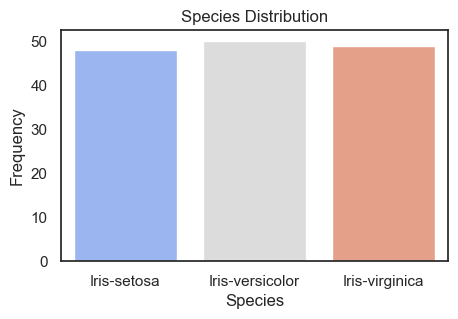

In [83]:
# Distribution of Species  
plt.figure(figsize=(5, 3))  
sns.countplot(data=df, x='Species', palette='coolwarm')  
plt.title("Species Distribution")  
plt.xlabel('Species')  
plt.ylabel('Frequency')  
plt.show() 

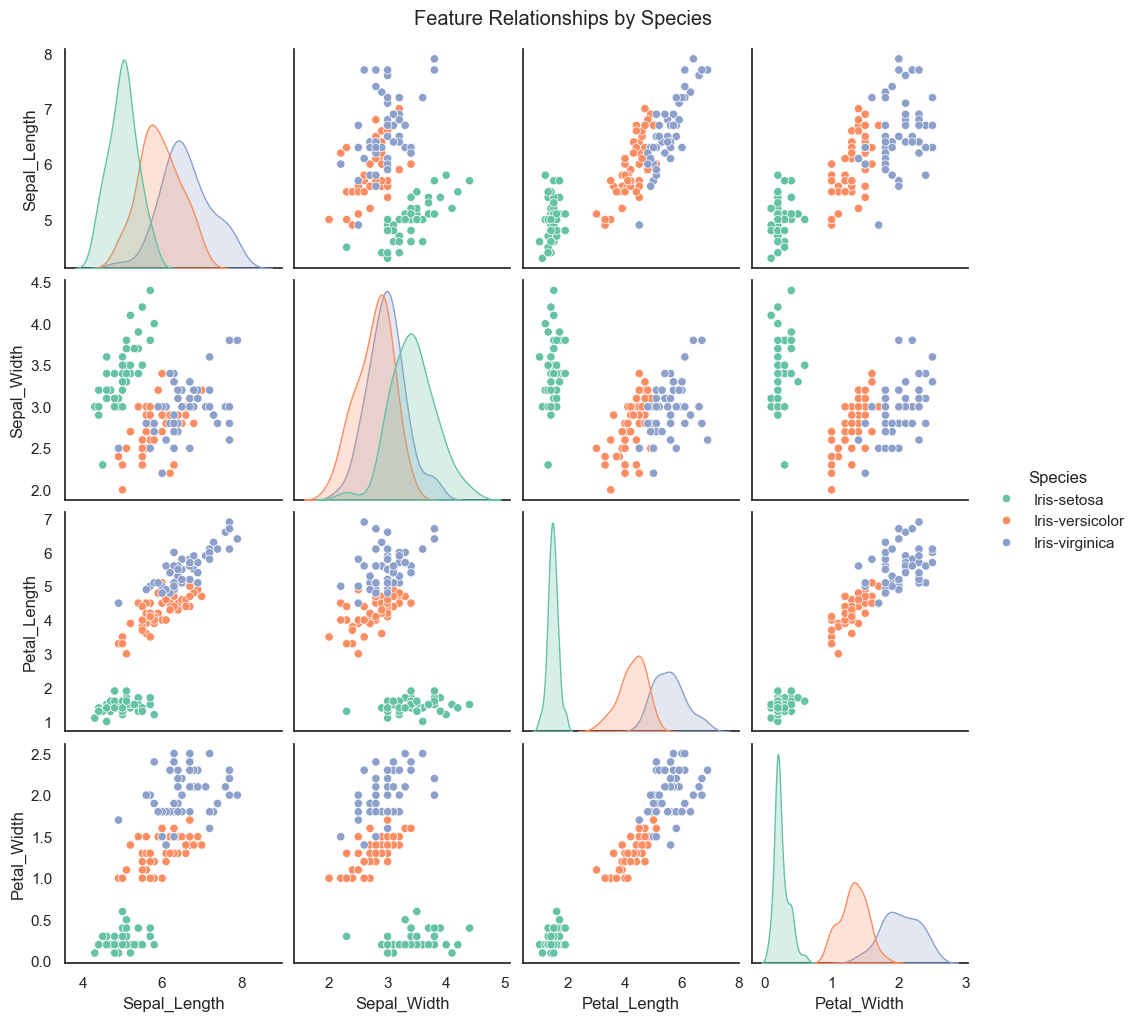

In [85]:
# Pairplot for feature relationships  
sns.pairplot(data=df, hue='Species', palette='Set2')  
plt.suptitle("Feature Relationships by Species", y=1.02)  
plt.show()

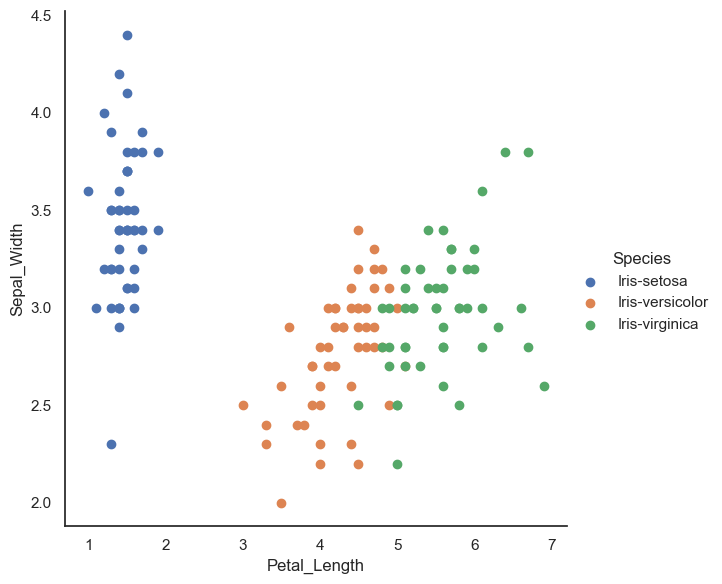

In [95]:
sns.FacetGrid(df, hue="Species", height=6)\
   .map(plt.scatter, "Petal_Length", "Sepal_Width")\
   .add_legend() 

In [93]:
# # Converting Categorical variables into number.
# flower_mapping = {'Iris-setosa':0, 'Iris-versicolor':1,'Iris-virginica':2}
# df["Species"] = df["Species"].map(flower_mapping)

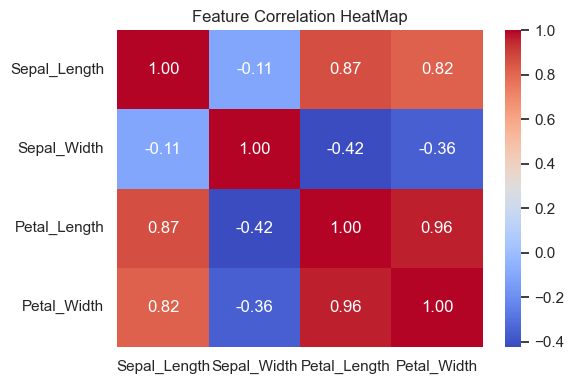

In [97]:
# Correlation Heatmap  
plt.figure(figsize=(6, 4))  
corr = df.select_dtypes(include=['number']).corr()  
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')  
plt.title('Feature Correlation HeatMap')  
plt.tight_layout()  
plt.show()  

In [99]:
# Step 3: Preprocessing
# Define input and output  
X = df.drop('Species', axis=1)  
y = df['Species']  

# Encode target variable  
le = LabelEncoder()  
y = le.fit_transform(y)  

# Train-test split  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5, stratify=y)  

In [101]:
# Step 4: Train Base Model (Random Forest)
# Initialize and train the model  
clf = RandomForestClassifier(random_state=5)  
clf.fit(X_train, y_train)  

# Make predictions  
y_train_pred = clf.predict(X_train)  
y_test_pred = clf.predict(X_test)  

In [103]:
# Step 5: Evaluate the Model
# Helper function to print evaluation metrics  
def evaluate_model(name, y_true, y_pred):  
    print(f"{name} Accuracy: {np.round(accuracy_score(y_true, y_pred), 3)}")  
    print(f"{name} Precision (Weighted): {np.round(precision_score(y_true, y_pred, average='weighted'), 3)}")  
    print(f"{name} Recall (Weighted): {np.round(recall_score(y_true, y_pred, average='weighted'), 3)}")  
    print(f"{name} F1 Score (Weighted): {np.round(f1_score(y_true, y_pred, average='weighted'), 3)}")  
    print()  

# Evaluate model  
evaluate_model("Training", y_train, y_train_pred)  
evaluate_model("Testing", y_test, y_test_pred)  


Training Accuracy: 1.0
Training Precision (Weighted): 1.0
Training Recall (Weighted): 1.0
Training F1 Score (Weighted): 1.0

Testing Accuracy: 0.933
Testing Precision (Weighted): 0.944
Testing Recall (Weighted): 0.933
Testing F1 Score (Weighted): 0.933



In [105]:
# Step 6: Hyperparameter Tuning (Optional-Grid search with cross-validation)
# Define parameter grid  
param_grid = {  
    'n_estimators': [50, 100],  
    'max_depth': [None, 5, 10],  
    'min_samples_split': [2, 5],  
    'min_samples_leaf': [1, 2]  
}  

# Grid search with cross-validation  
grid_search = GridSearchCV(RandomForestClassifier(random_state=5), param_grid, cv=5, scoring='accuracy', n_jobs=-1)  
grid_search.fit(X_train, y_train)  

# Best model  
best_clf = grid_search.best_estimator_  

# Predictions with best model  
y_train_pred = best_clf.predict(X_train)  
y_test_pred = best_clf.predict(X_test)  

# Re-evaluate  
evaluate_model("Best Model - Training", y_train, y_train_pred)  
evaluate_model("Best Model - Testing", y_test, y_test_pred)  


Best Model - Training Accuracy: 1.0
Best Model - Training Precision (Weighted): 1.0
Best Model - Training Recall (Weighted): 1.0
Best Model - Training F1 Score (Weighted): 1.0

Best Model - Testing Accuracy: 0.967
Best Model - Testing Precision (Weighted): 0.97
Best Model - Testing Recall (Weighted): 0.967
Best Model - Testing F1 Score (Weighted): 0.967



In [109]:
# Step 7: Save the Best Model
import pickle  

# Save the best model  
with open('random_forest_classifier_iris.pkl', 'wb') as file:  
    pickle.dump(best_clf, file)  
